In [1]:
# The instructor started by ignoring warnings because this dataset throws a lot of them.
import warnings
warnings.filterwarnings('ignore')

# Importing basic libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the boom bikes dataset
# Note: Ensure the csv is in the same folder as the Jupyter Notebook
dataset = pd.read_csv('data.csv') 

# Let's check the basic details of the dataset as shown in the video
# dataset.head()
# print(dataset.shape) # Gives 730 rows (2 years of data: 365 + 365)
# print(dataset.columns)
# print(dataset.describe()) # Check mean values, temp is around 20 degrees
# print(dataset.info()) # Checks for nulls (there are no non-null characters/missing data)

# Mapping Categorical Variables to Strings

# The instructor mentioned that keeping numeric values for categories (like season=1) 
# might misindicate some specific order to the machine learning model. 
# We need to map them to strings.

# 1. Season Mapping
# 1: spring, 2: summer, 3: fall, 4: winter
dataset.loc[dataset['season'] == 1, 'season'] = 'spring'
dataset.loc[dataset['season'] == 2, 'season'] = 'summer'
dataset.loc[dataset['season'] == 3, 'season'] = 'fall'
dataset.loc[dataset['season'] == 4, 'season'] = 'winter'

# Checking if mapping worked and values are balanced
# print(dataset['season'].astype('category').value_counts())

# 2. Year Mapping 
# 0 = 2018, 1 = 2019 (Leaving this as numeric 0 and 1 since it indicates a trend/growth)
# print(dataset['yr'].value_counts()) # Exactly 365 days for each

# 3. Month Mapping
# Instead of doing .loc 12 times, the instructor used a dictionary map
month_map = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 
             7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
dataset['mnth'] = dataset['mnth'].map(month_map)

# 4. Weekday Mapping
# Based on the calendar, mapping numeric days to actual string days
weekday_map = {0: 'Sunday', 1: 'Monday', 2: 'Tuesday', 3: 'Wednesday', 
               4: 'Thursday', 5: 'Friday', 6: 'Saturday'}
dataset['weekday'] = dataset['weekday'].map(weekday_map)

# 5. Weather Situation Mapping
# 1: Clear/Partly Cloudy (A), 2: Mist/Cloudy (B), 3: Light Snow/Rain (C)
weather_map = {1: 'A', 2: 'B', 3: 'C'}
dataset['weathersit'] = dataset['weathersit'].map(weather_map)

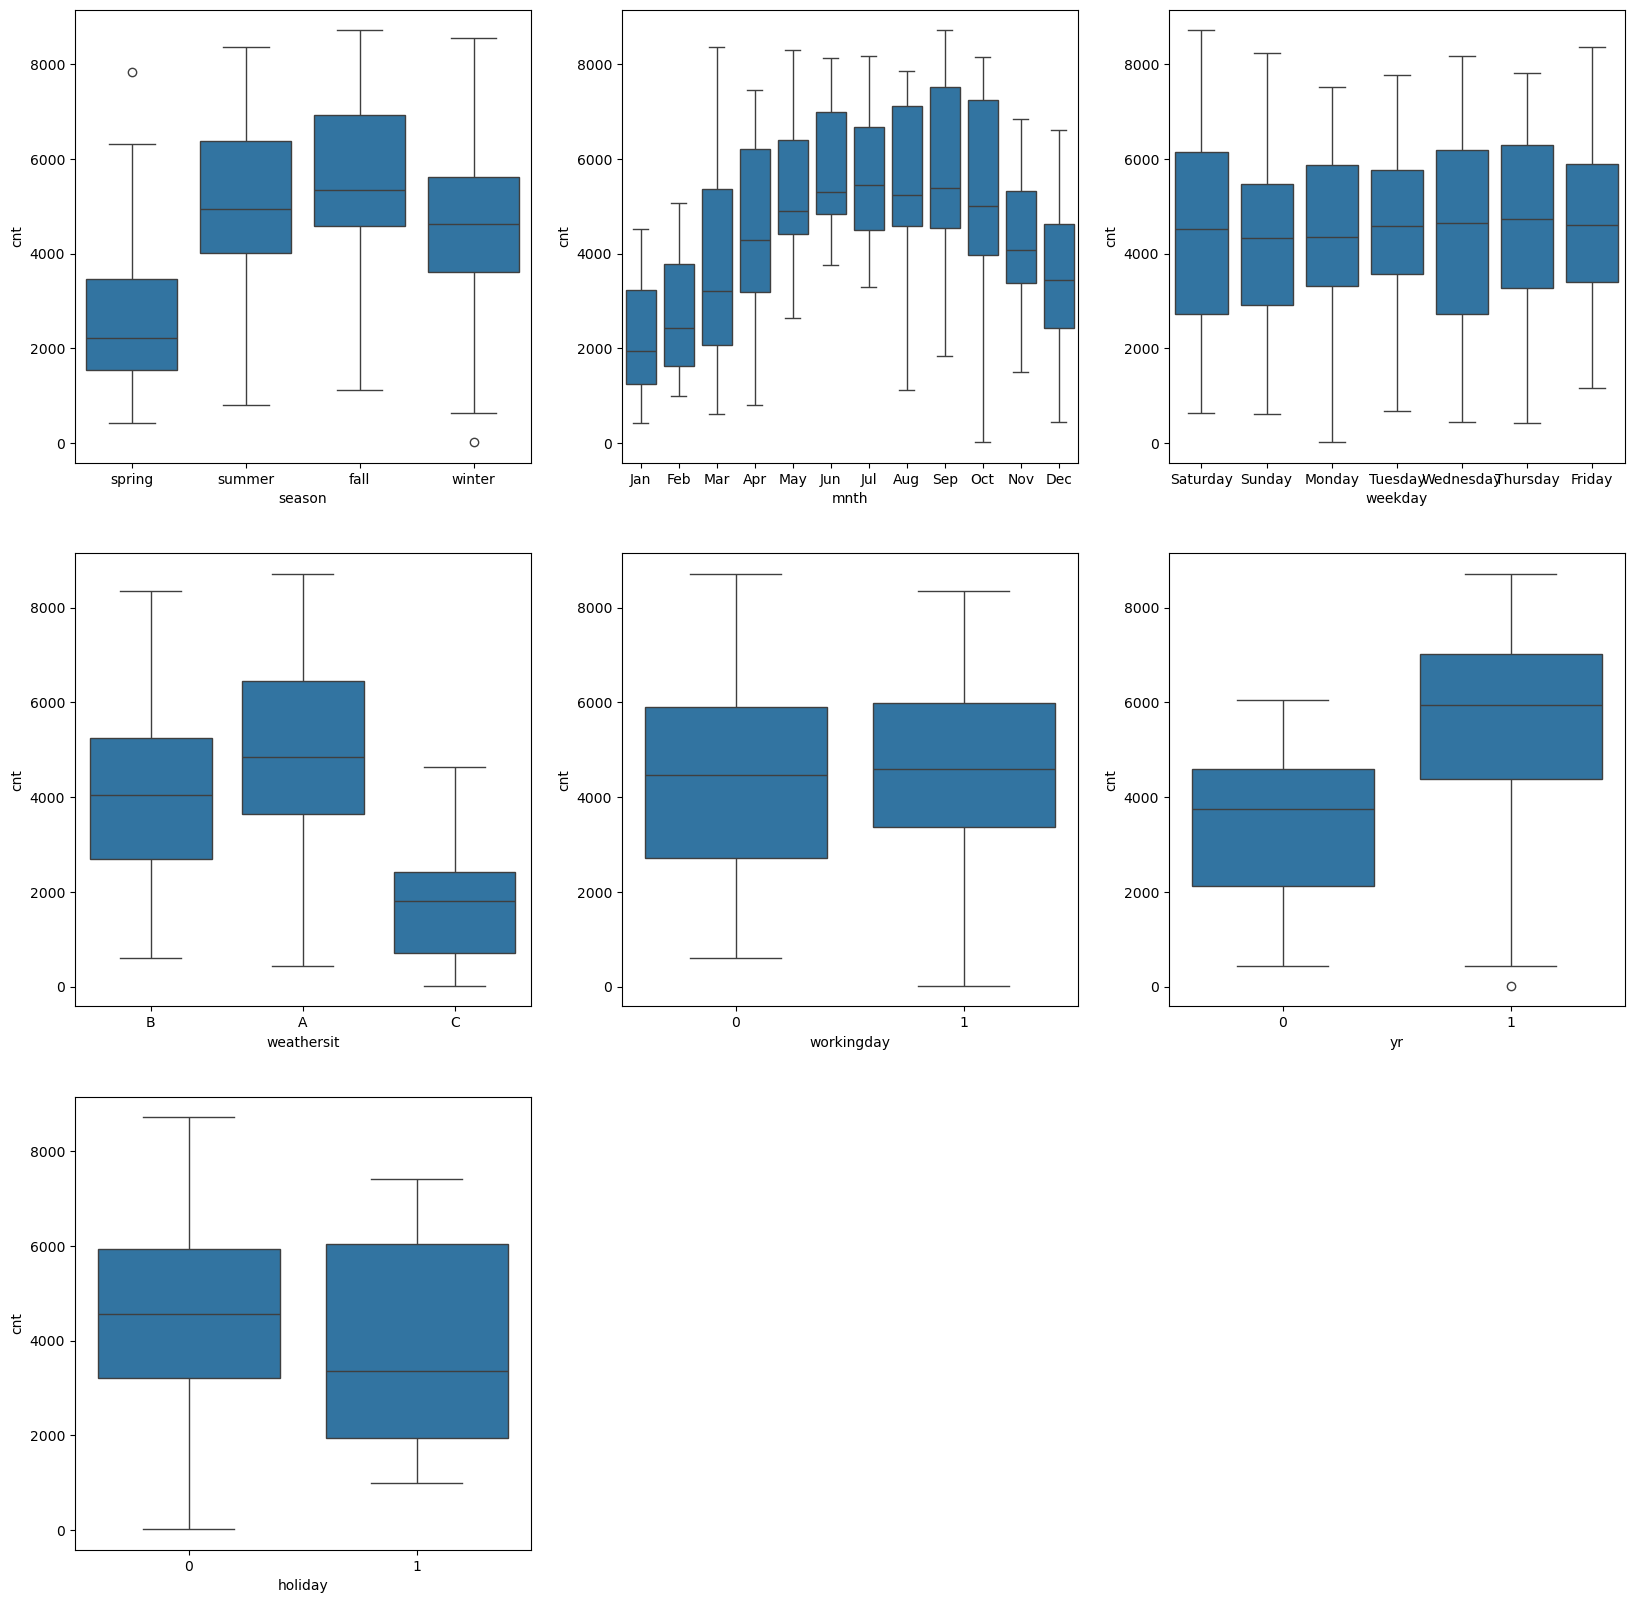

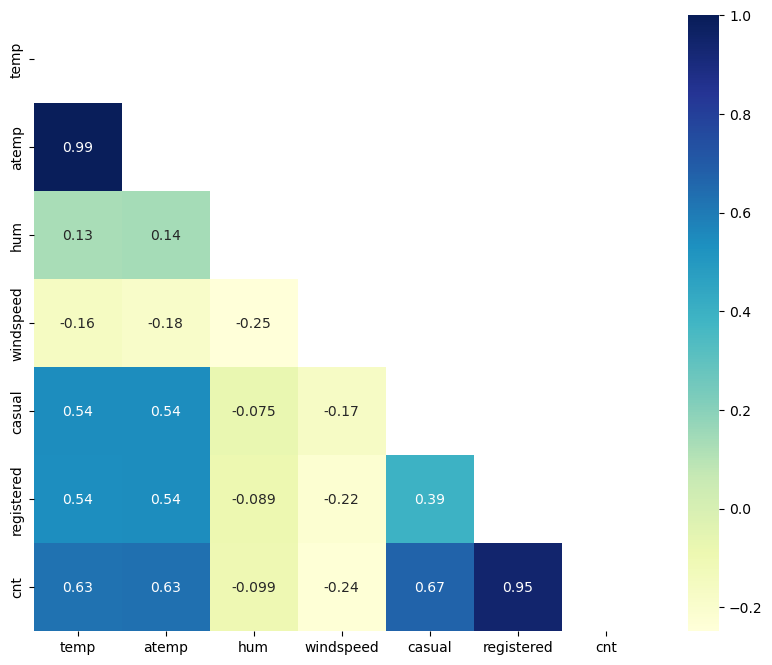

In [2]:
# Visualizing continuous variables using distribution plots
# Note: In Jupyter, plt.show() renders the plot.
# sns.distplot(dataset['temp'])
# plt.show()
# sns.distplot(dataset['atemp']) # This curve looks almost identical to 'temp'
# plt.show()
# sns.distplot(dataset['windspeed'])
# plt.show()

# Visualizing the Target Variable ('cnt' - Total rental bikes including casual & registered)
# sns.distplot(dataset['cnt'])
# plt.show()

# Converting 'dteday' from object to datetime format
dataset['dteday'] = dataset['dteday'].astype('datetime64[ns]')

# Extracting categorical variables (excluding float64 and int64) to plot them
dataset_categorical = dataset.select_dtypes(exclude=['float64', 'int64', 'datetime64[ns]'])
# print(dataset_categorical.columns) # season, mnth, weekday, weathersit

# Visualizing categorical variables against target 'cnt' using Boxplots
plt.figure(figsize=(20, 20))

plt.subplot(3, 3, 1)
sns.boxplot(x='season', y='cnt', data=dataset)
# Note: Spring has the lowest demand. Fall has the highest.

plt.subplot(3, 3, 2)
sns.boxplot(x='mnth', y='cnt', data=dataset)

plt.subplot(3, 3, 3)
sns.boxplot(x='weekday', y='cnt', data=dataset)
# Note: Median demand is pretty similar across all days of the week.

plt.subplot(3, 3, 4)
sns.boxplot(x='weathersit', y='cnt', data=dataset)
# Note: Weather 'A' (Clear) has higher demand than 'C' (Snow/Rain).

plt.subplot(3, 3, 5)
sns.boxplot(x='workingday', y='cnt', data=dataset)

plt.subplot(3, 3, 6)
sns.boxplot(x='yr', y='cnt', data=dataset)
# Note: Crucial insight! 2019 (1) has drastically higher demand than 2018 (0). Year is a strong predictor.

plt.subplot(3, 3, 7)
sns.boxplot(x='holiday', y='cnt', data=dataset)

plt.show()

# Converting numerical target-related columns to float to view in pairplot
var_list = ['casual', 'registered', 'cnt']
for var in var_list:
    dataset[var] = dataset[var].astype(float)

data_numeric = dataset.select_dtypes(include=['float64'])

# Pairplot to check numerical relationships
# sns.pairplot(data_numeric)
# plt.show()

# Correlation Matrix & Heatmap for numerical variables
cor_relationship = data_numeric.corr()

# Creating a mask to hide the upper triangle since the matrix is symmetric (instructor sets to lower triangle)
mask = np.triu(np.ones_like(cor_relationship, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(cor_relationship, mask=mask, vmax=1, square=True, annot=True, cmap='YlGnBu')
plt.show()

# INSIGHT: 'temp' and 'atemp' (actual temperature) are almost 99% highly correlated.
# To avoid multicollinearity, we drop 'atemp'.
dataset.drop(['atemp'], axis=1, inplace=True)

In [3]:
# We need to create dummy variables for our categorical text objects (season, mnth, weekday, weathersit)
dataset_categorical = dataset.select_dtypes(include=['object'])

# Generating dummy variables. 'drop_first=True' is used to avoid the dummy variable trap.
# Example: If a month is not Feb-Dec, it is inherently Jan.
dataset_dummies = pd.get_dummies(dataset_categorical, drop_first=True, dtype=int)

# Dropping the original text columns from the main dataset
dataset.drop(list(dataset_categorical.columns), axis=1, inplace=True)

# Concatenating the new dummy variables to the main dataset
dataset = pd.concat([dataset, dataset_dummies], axis=1)

# Dropping irrelevant features that don't add significance for our regression
# 'dteday' (date) is dropped because we already extracted year/month/weekday info.
# 'instant' is just a row index.
dataset.drop(['dteday', 'instant'], axis=1, inplace=True)

# print(dataset.shape) # The dataset now has expanded columns due to dummies.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

# 1. Splitting the Data
# Random seed for reproducibility
np.random.seed(0)

# Splitting 70% train and 30% test
df_train, df_test = train_test_split(dataset, train_size=0.7, test_size=0.3, random_state=100)

# 2. Feature Scaling
# We use MinMaxScaler to bring everything to a 0-1 range so continuous variables have equal weightage
scaler = MinMaxScaler()

# We scale only the continuous numeric variables, not the dummy variables (which are already 0 and 1)
num_vars = ['temp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']

# Fit and transform the training data
df_train[num_vars] = scaler.fit_transform(df_train[num_vars])

# Visualizing correlations post-scaling
# plt.figure(figsize=(30, 30))
# sns.heatmap(df_train.corr(), annot=True, cmap='YlGnBu')
# plt.show()

# 3. Dividing into X (independent) and Y (dependent)
# The instructor realized 'casual' and 'registered' add up exactly to 'cnt' (target). 
# If left in, it predicts perfectly (1.0 R-squared) which is cheating. We drop them.
X_train = df_train.drop(['casual', 'registered'], axis=1)

# 'cnt' is our target variable, so we pop it from X_train into y_train
y_train = X_train.pop('cnt')

# 4. Building the Model using StatsModels (Ordinary Least Squares)
# We add a constant manually because StatsModels doesn't include an intercept by default.
X_train_lm = sm.add_constant(X_train)
lm = sm.OLS(y_train, X_train_lm).fit()

# Checking the summary of the model
print(lm.summary())
# NOTE: The instructor got an adjusted R-squared of 84.2% after fixing the target leakage bug!

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.853
Model:                            OLS   Adj. R-squared:                  0.845
Method:                 Least Squares   F-statistic:                     103.8
Date:                Fri, 31 Jul 2026   Prob (F-statistic):          8.74e-182
Time:                        23:51:50   Log-Likelihood:                 527.95
No. Observations:                 510   AIC:                            -999.9
Df Residuals:                     482   BIC:                            -881.3
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.2451      0.03

In [5]:
from sklearn.feature_selection import RFE
from statsmodels.stats.outliers_influence import variance_inflation_factor

# The model has almost 29 features. We want to reduce complexity and remove less significant ones.
lm_rfe = LinearRegression()

# 1. RFE with 15 features
rfe1 = RFE(lm_rfe, n_features_to_select=15)
rfe1.fit(X_train, y_train)

# Checking which features were selected (True) and their rankings
# print(rfe1.support_)
# print(rfe1.ranking_)

# Creating a new subset with only the 15 selected columns
col1 = X_train.columns[rfe1.support_]
X_train_rfe1 = X_train[col1]

# Rebuilding the model with these 15 features
X_train_lm1 = sm.add_constant(X_train_rfe1)
lm1 = sm.OLS(y_train, X_train_lm1).fit()
# print(lm1.summary()) # Adjusted R-squared dropped minimally to 84.1%. Good sign!

# 2. RFE with 7 features
# Instructor tries limiting it down to just 7 features to see the impact.
rfe2 = RFE(lm_rfe, n_features_to_select=7)
rfe2.fit(X_train, y_train)

col2 = X_train.columns[rfe2.support_]
X_train_rfe2 = X_train[col2]

X_train_lm2 = sm.add_constant(X_train_rfe2)
lm2 = sm.OLS(y_train, X_train_lm2).fit()
# print(lm2.summary()) # Adjusted R-squared drops a bit more to 81.1%, still very good for just 7 features.

# 3. Variance Inflation Factor (VIF)
# This checks for multicollinearity (features heavily predicting each other)
# Instructor drops 'const' before checking VIF
X_train_vif = X_train_lm2.drop(['const'], axis=1)

vif = pd.DataFrame()
vif['Features'] = X_train_vif.columns
vif['VIF'] = [variance_inflation_factor(X_train_vif.values, i) for i in range(X_train_vif.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by="VIF", ascending=False)
# print(vif)
# Note: If humidity or temp have high VIF, we could drop them iteratively to improve t

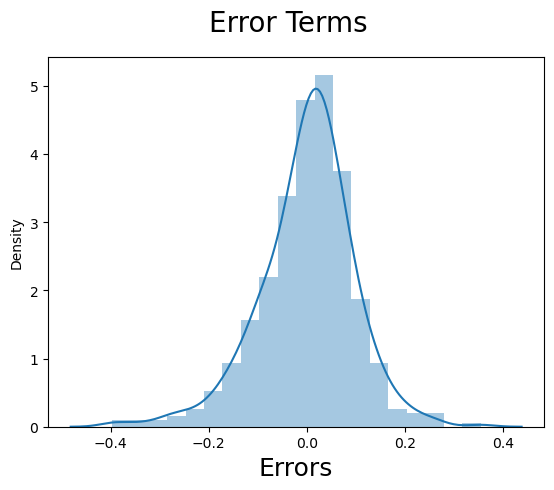

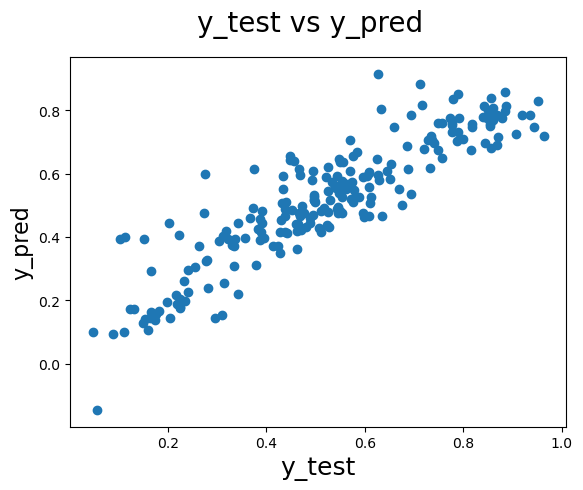

In [6]:
# Predicting on the training set to check error terms
y_train_cnt = lm2.predict(X_train_lm2)

# Plotting the residuals (Error terms)
fig = plt.figure()
sns.distplot((y_train - y_train_cnt), bins=20)
fig.suptitle('Error Terms', fontsize=20)
plt.xlabel('Errors', fontsize=18)
plt.show()
# Note: The error terms seem fairly normally distributed.

# PREPARING TEST DATA
# We only use .transform() on test data, NOT .fit_transform(), so we don't leak logic from train.
df_test[num_vars] = scaler.transform(df_test[num_vars])

# Isolating test X and y (dropping cheating variables again)
X_test = df_test.drop(['casual', 'registered'], axis=1)
y_test = X_test.pop('cnt')

# Subsetting test variables down to the 7 features selected by RFE2
X_test_rfe2 = X_test[col2]

# Adding constant for statsmodels
X_test_lm2 = sm.add_constant(X_test_rfe2)

# Predicting on Test Data
y_pred = lm2.predict(X_test_lm2)

# Visualizing predicted vs actual Test data
fig = plt.figure()
plt.scatter(y_test, y_pred)
fig.suptitle('y_test vs y_pred', fontsize=20)
plt.xlabel('y_test', fontsize=18)
plt.ylabel('y_pred', fontsize=16)
plt.show()

# Final Evaluation Metric: R-squared Score
from sklearn.metrics import r2_score
final_score = r2_score(y_test, y_pred)
# print("Test R2 Score:", final_score) 
# Note: Instructor got 80.52%, indicating a robust and consistent model!